<h3>Nicholas</h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("cleaned_dataset.csv")
df.describe()


,id,time_in_hours,rush_hour,vehicle_count,male_count,female_count,total_driver_count,min_age,max_age,young_driver_involved,adult_driver_involved,senior_driver_involved,child_involved,senior_involved,visibility,wind_speed,temperature,ambulance_called
count,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,264.000000,280.000000,280.000000,280.000000
mean,209.357143,1205.639286,0.239286,1.657143,1.425000,0.523214,1.585714,36.083929,51.157143,0.214286,0.925000,0.253571,0.060714,0.382143,9.958333,22.201183,22.890152,0.953571
std,125.756781,626.626241,0.427411,0.620977,0.729376,0.691990,0.584884,15.570257,17.396606,0.436436,0.631959,0.467574,0.267525,0.622490,0.362405,11.940821,6.589286,0.210788
min,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,10.000000,0.000000
25%,113.750000,800.000000,0.000000,1.000000,1.000000,0.000000,1.000000,25.000000,36.000000,0.000000,1.000000,0.000000,0.000000,0.000000,10.000000,14.800000,17.000000,1.000000
50%,200.500000,1215.000000,0.000000,2.000000,1.000000,0.000000,2.000000,33.000000,52.000000,0.000000,1.000000,0.000000,0.000000,0.000000,10.000000,20.400000,22.945076,1.000000
75%,311.250000,1730.000000,0.000000,2.000000,2.000000,1.000000,2.000000,44.000000,64.000000,0.000000,1.000000,0.000000,0.000000,1.000000,10.000000,27.800000,28.000000,1.000000
max,430.000000,2359.000000,1.000000,3.500000,3.500000,2.500000,3.500000,72.500000,87.000000,2.000000,3.000000,2.000000,2.000000,4.000000,10.000000,47.300000,38.000000,1.000000


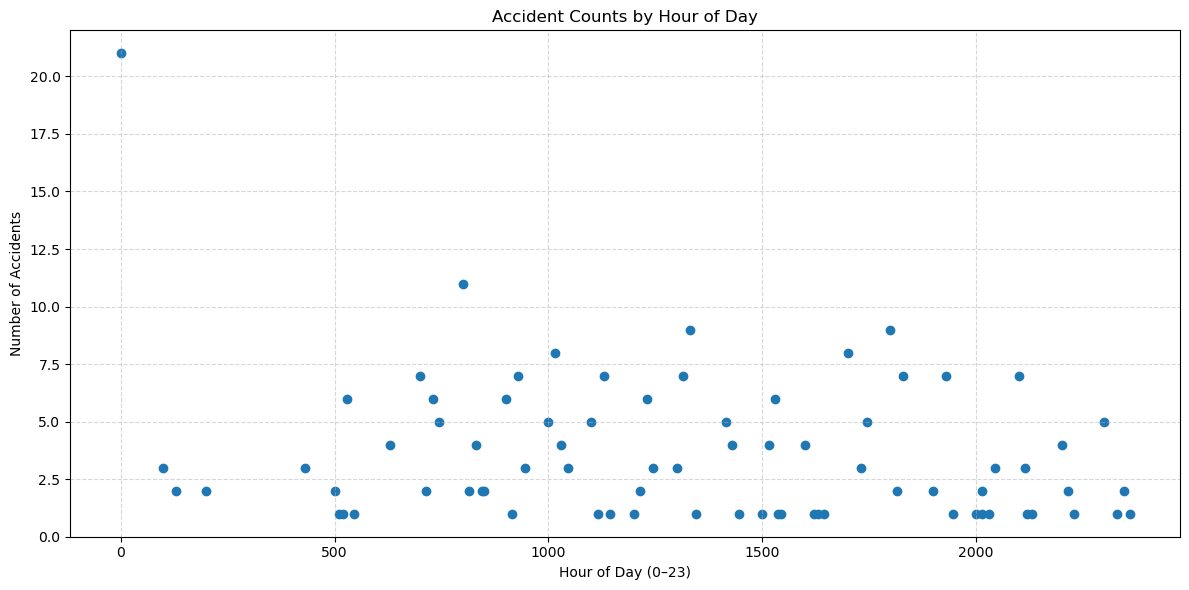

In [ ]:


# Ensure time_in_hours is numeric
df["time_in_hours"] = pd.to_numeric(df["time_in_hours"], errors="coerce")

# Count accidents per hour
hour_counts = df["time_in_hours"].value_counts().sort_index()

# Scatter plot
plt.figure(figsize=(12,6))
plt.scatter(hour_counts.index, hour_counts.values)

plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Accidents")
plt.title("Accident Counts by Hour of Day")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\nicho\AppData\Local\Temp\ipykernel_23592\3483617935.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_exp.pivot_table(


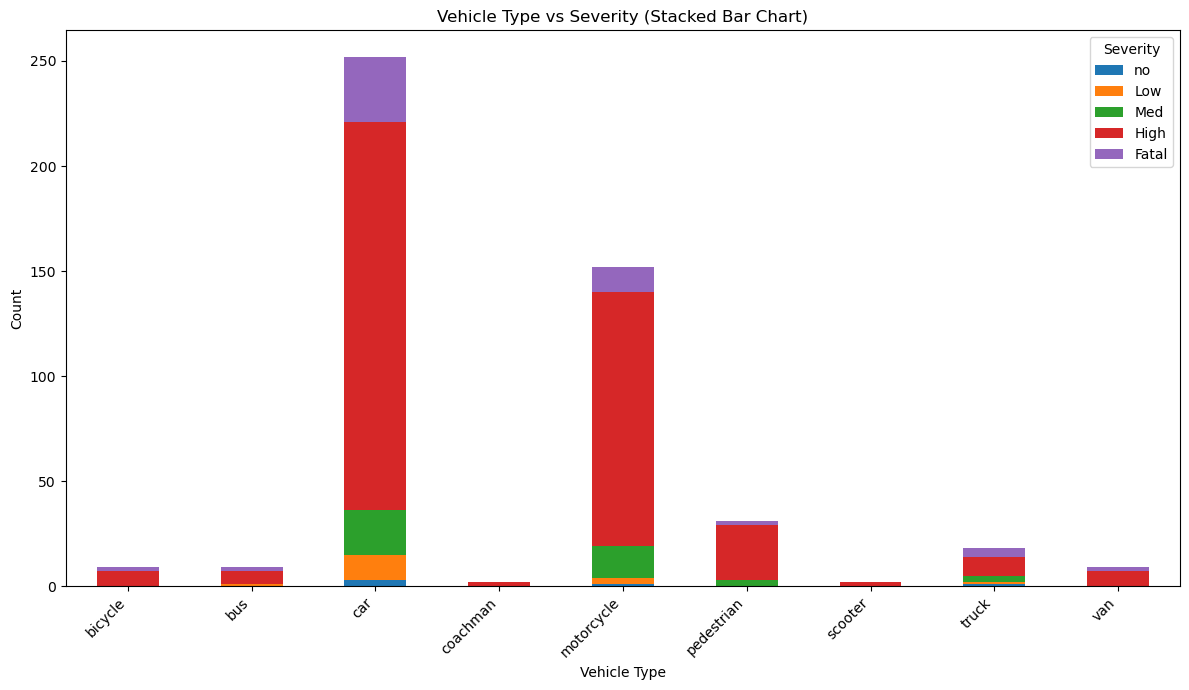

In [3]:
# Normalize severity case
severity_order = ['no', 'Low', 'Med', 'High', 'Fatal']
df['severity'] = (
    df['severity'].astype(str)
    .str.strip()
    .str.capitalize()
    .replace({'No': 'no'})
)
df['severity'] = pd.Categorical(df['severity'], categories=severity_order, ordered=True)

# Sort vehicle parts alphabetically so car-motorcycle == motorcycle-car
df['vehicle_normalized'] = (
    df['vehicle_involved']
      .astype(str)
      .str.lower()
      .str.replace(r'[^a-z-]', '', regex=True)
      .str.split('-')
      .apply(lambda x: '-'.join(sorted([i.strip() for i in x if i.strip()]))) #removes " " from list sorts alphabetically and joins back ex: ["motorcycle ", "","car"] -> ["car", "motorcycle"]
)

# Split into individual vehicle types
df['vehicle_list'] = df['vehicle_normalized'].str.split('-')

# Explode to individual rows per vehicle
df_exp = df.explode('vehicle_list')
df_exp.rename(columns={'vehicle_list': 'vehicle_type'}, inplace=True)

pivot = df_exp.pivot_table(
    index="vehicle_type",
    columns="severity",
    aggfunc='size',
    fill_value=0
)

pivot.plot(kind='bar', stacked=True, figsize=(12, 7))

plt.title("Vehicle Type vs Severity (Stacked Bar Chart)")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Severity")
plt.tight_layout()

plt.show()


<h3>Richard</h3>

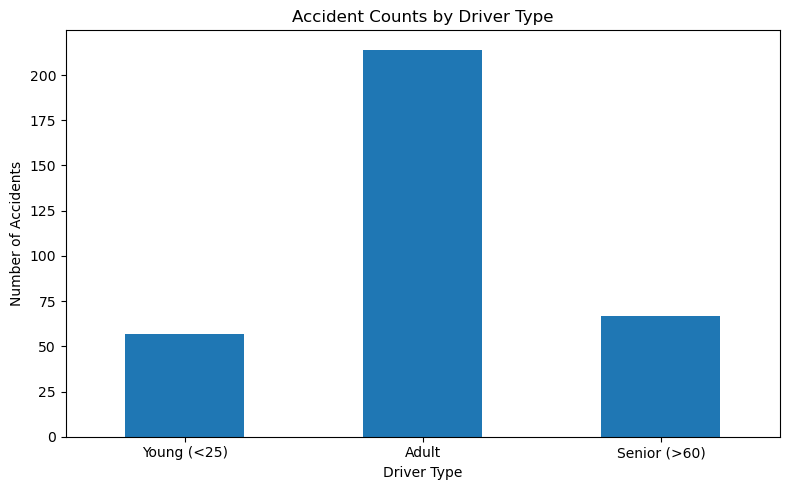

In [7]:

# Select the driver type columns
driver_cols = [
    'young_driver_involved',
    'adult_driver_involved',
    'senior_driver_involved'
]

# Count how many accidents include each driver type
driver_counts = df[driver_cols].apply(lambda col: col.astype(bool).sum())

# Rename for cleaner chart labels
driver_counts.index = ["Young (<25)", "Adult", "Senior (>60)"]

# Plot the bar chart
plt.figure(figsize=(8,5))
driver_counts.plot(kind='bar')

plt.title("Accident Counts by Driver Type")
plt.xlabel("Driver Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()

# Display chart
plt.show()

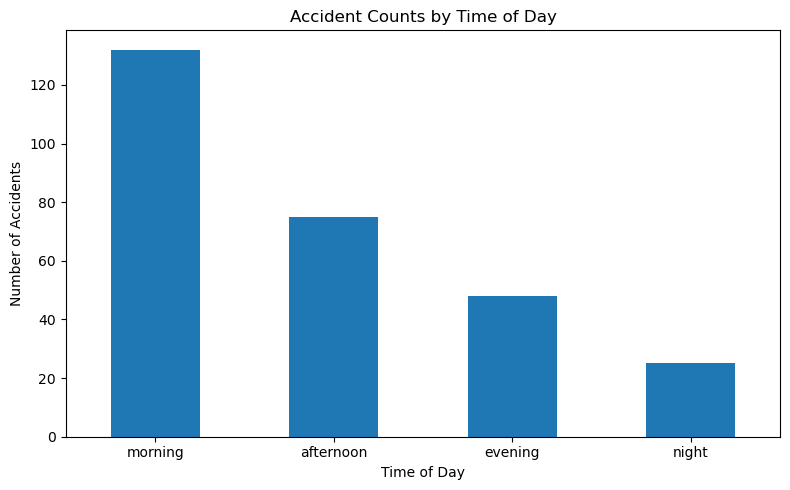

In [8]:
# Count accidents per time-of-day category
counts = df['time'].value_counts().reindex(["morning", "afternoon", "evening", "night"])

# Create the bar chart
plt.figure(figsize=(8,5))
counts.plot(kind='bar')

plt.title("Accident Counts by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

<h3>Michele</h3>

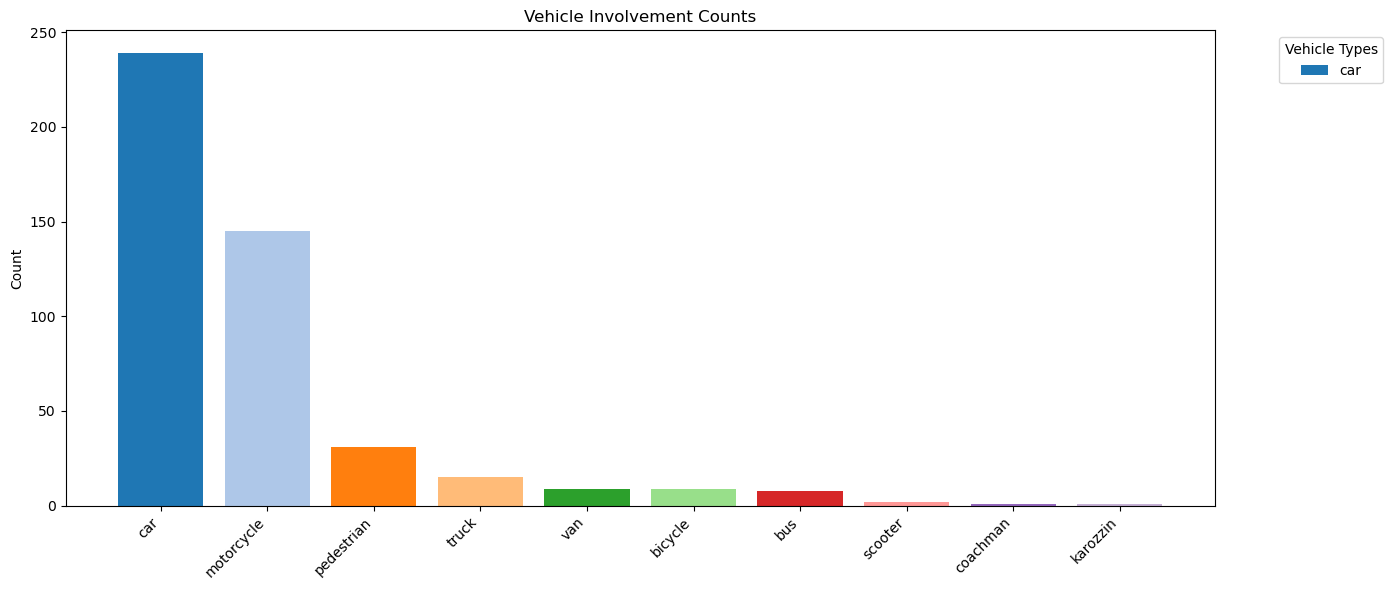

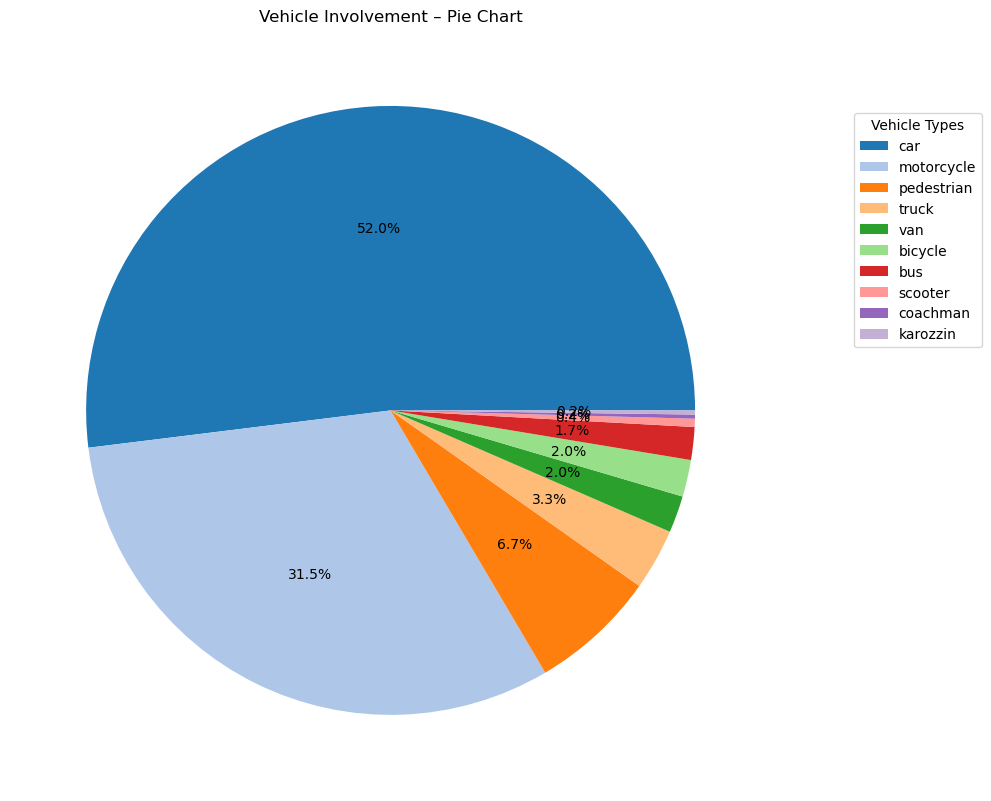

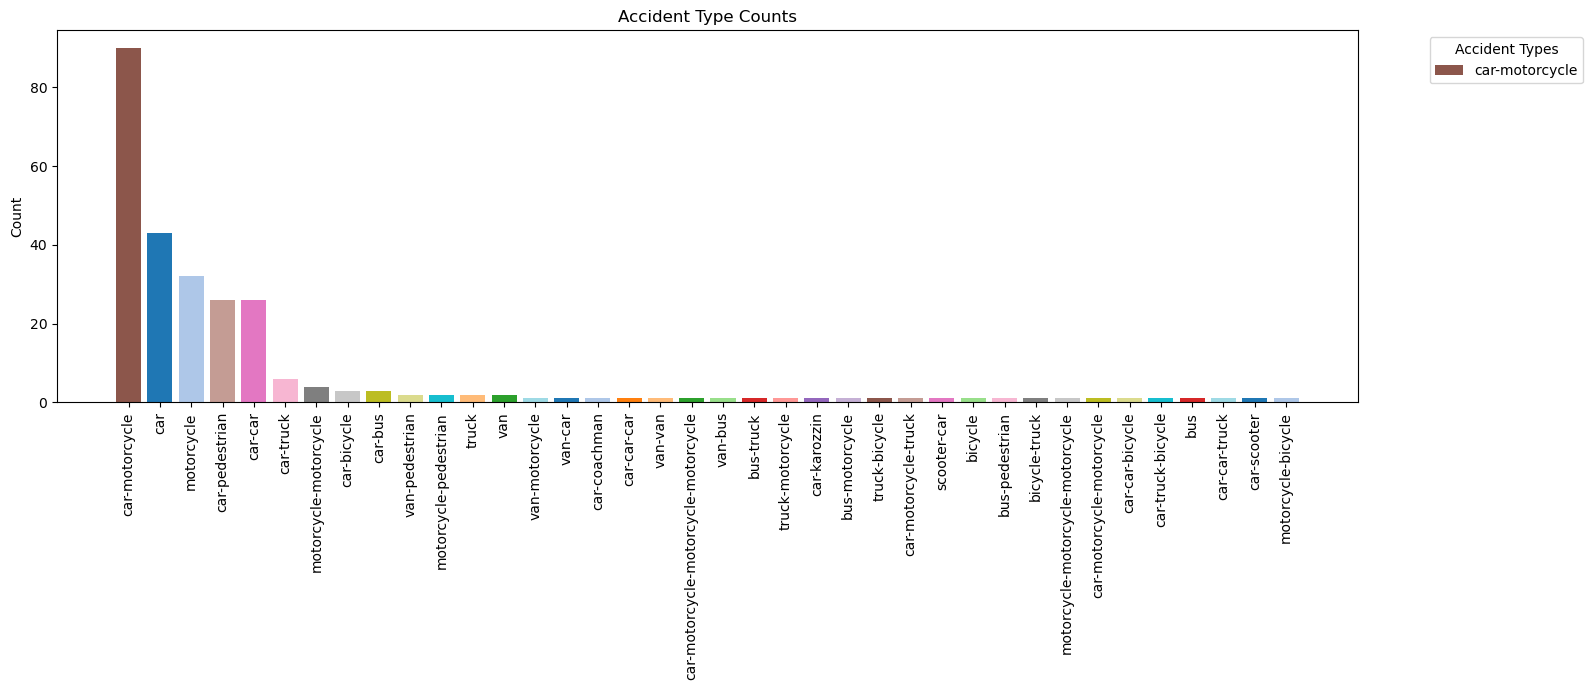

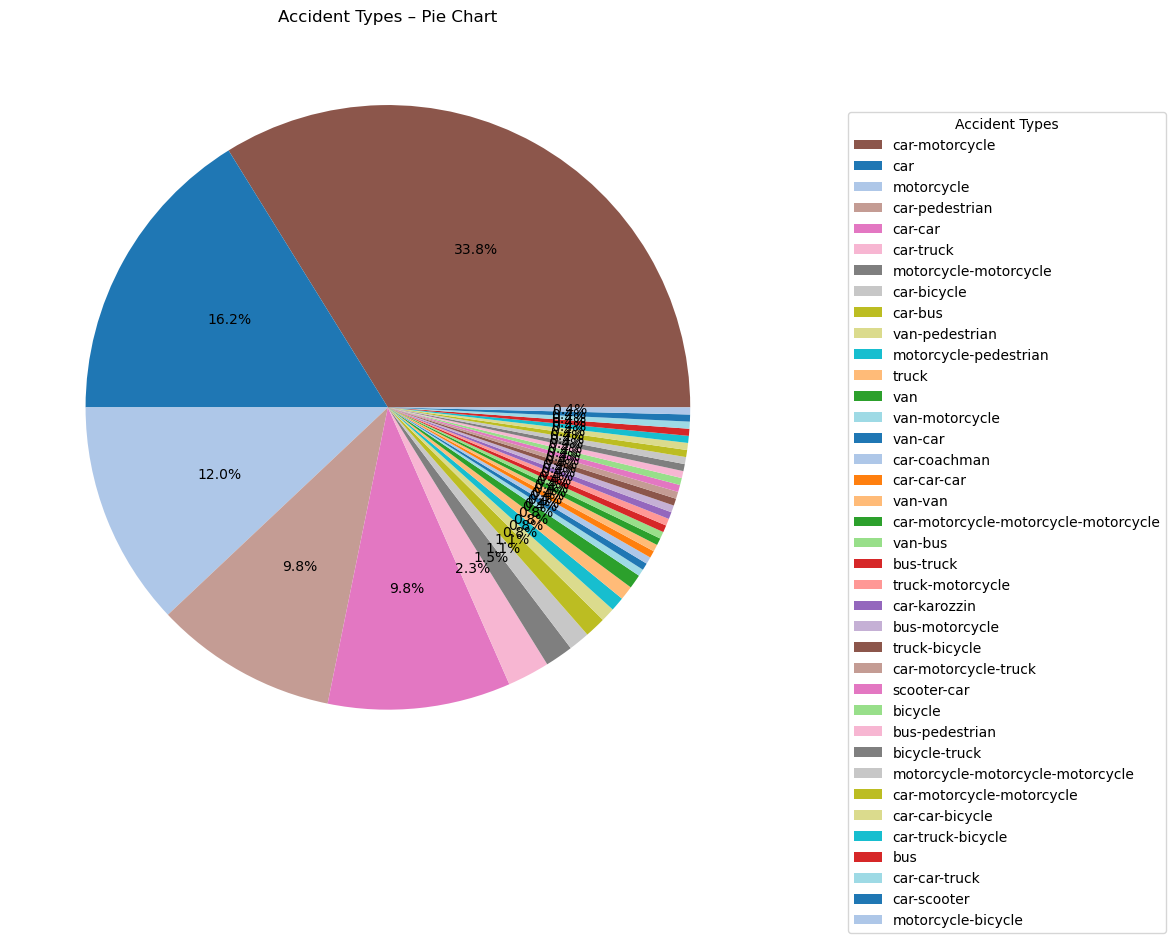

In [9]:
import matplotlib.pyplot as plt
from collections import Counter
import re


raw = """car-motorcycle
car-motorcycle
van-motorcycle
car-motorcycle
car-motorcycle
car-motorcycle
van-car
motorcycle-motorcycle
car-motorcycle
car-pedestrian
motorcycle
car-pedestrian
car-pedestrian
motorcycle
car-pedestrian
van-pedestrian
car
car-bicycle
car-coachman
car
car-motorcycle
car-car
van-pedestrian
car-motorcycle
car
motorcycle
car
car-car-car
car-motorcycle
motorcycle
car-pedestrian
car-motorcycle
car-pedestrian
van-van
motorcycle
car-pedestrian
motorcycle-pedestrian
car-motorcycle-motorcycle-motorcycle
car-bicycle
van-bus
car
car-motorcycle
car
car-car
car-pedestrian
car-pedestrian
car
car-motorcycle
motorcycle
car-pedestrian
car-motorcycle
car-car
car-motorcycle
motorcycle
car-motorcycle
car
car-motorcycle
car-motorcycle
motorcycle
car-motorcycle
car
car
car-motorcycle
car-truck
car-motorcycle
car-car
car-motorcycle
car-pedestrian
car-motorcycle
car-motorcycle
car-motorcycle
car-motorcycle
car-car
motorcycle 
car-pedestrian
car-pedestrian
car
motorcycle 
car-motorcycle
car-motorcycle
car-pedestrian
car-motorcycle
car
bus-truck
car
car-motorcycle
car
car-bus
car-motorcycle
car-motorcycle
car-motorcycle
car
motorcycle 
car-motorcycle
car-motorcycle
car-motorcycle
truck-motorcycle
car
car-karozzin
car-motorcycle
car
car-motorcycle
motorcycle 
car
car
car-bus
truck
car-car
car-pedestrian
motorcycle 
Bus-motorcycle
car-truck
car-pedestrian
car
motorcycle
car-motorcycle
car-motorcycle
car-car
truck-bicycle
car
car-motorcycle
car-motorcycle
car-bus
car-car
car-motorcycle-truck
car-motorcycle
car-pedestrian
motorcycle
car-motorcycle
car-motorcycle
car-car
motorcycle
car-motorcycle
motorcycle
car-motorcycle
car-motorcycle
car-motorcycle
car-motorcycle
car-motorcycle
car-motorcycle
car-truck
car-motorcycle
car-motorcycle
car 
scooter-car
bicycle
car-car
motorcycle
motorcycle
car-motorcycle
car-car
car-motorcycle
motorcycle
bus-pedestrian
car-motorcycle
car-motorcycle

car-motorcycle

car
car-motorcycle
car-pedestrian
motorcycle
motorcycle
car-pedestrian
bicycle-truck
car-motorcycle
motorcycle-pedestrian
car-pedestrian
motorcycle-motorcycle-motorcycle
car-pedestrian
motorcycle
car-motorcycle
car-bicycle
car-motorcycle
car-pedestrian
motorcycle-motorcycle
car-car
motorcycle
car-motorcycle
car-pedestrian
car-motorcycle motorcycle
car-car-bicycle
motorcycle-motorcycle
car-pedestrian
car-motorcycle
car-car
car
car-motorcycle
car-pedestrian
motorcycle
car
car-motorcycle
car-car
car-motorcycle
motorcycle
truck
car-truck-bicycle
motorcycle
car-motorcycle
bus
car-car
car-pedestrian
car-motorcycle
car-car-truck
car
car-car
car
car-motorcycle
car
car-motorcycle
motorcycle
car
van
car-car
car-motorcycle
car-motorcycle
car-motorcycle
car-car
car-motorcycle
car
van
motorcycle
car-car
car
car-motorcycle
car-motorcycle
car
motorcycle
car-truck
car
car-scooter
car-car
car-motorcycle
car-car
car-motorcycle
car-motorcycle

car-motorcycle
car-car
car-truck
car-motorcycle
car-motorcycle
motorcycle

car-car
motorcycle-bicycle
car
car
car-motorcycle

car
car
car-truck
car-motorcycle
motorcycle-motorcycle
car
car-car
car
motorcycle
car-motorcycle

car-motorcycle
car
car-motorcycle
car
car-car
car
car-motorcycle

car-motorcycle
car
car-car"""

lines = [l.strip() for l in raw.splitlines() if l.strip()]

# counting of individual vehicles
vehicles = Counter()
for line in lines:
    parts = re.split(r"[-\s]+", line.lower())
    for p in parts:
        vehicles[p] += 1

# normalizing of accident type names
def normalize(text):
    parts = re.split(r"[-\s]+", text.strip().lower())
    return "-".join(parts)

accident_types = Counter(normalize(t) for t in lines)

# sorting for readability
vehicles = dict(sorted(vehicles.items(), key=lambda x: x[1], reverse=True))
accident_types = dict(sorted(accident_types.items(), key=lambda x: x[1], reverse=True))

# plotting with legend and colour key

# choose consistent color mapping
unique_labels = list(vehicles.keys()) + list(accident_types.keys())
unique_labels = list(dict.fromkeys(unique_labels))  # remove duplicates
colors = plt.cm.tab20(range(len(unique_labels)))     # 20 distinct colours

color_map = {label: colors[i % 20] for i, label in enumerate(unique_labels)}

# histogram for vehicles

plt.figure(figsize=(14, 6))
plt.bar(vehicles.keys(),
        vehicles.values(),
        color=[color_map[v] for v in vehicles.keys()])
plt.xticks(rotation=45, ha='right')
plt.title("Vehicle Involvement Counts")
plt.ylabel("Count")

plt.legend(vehicles.keys(), title="Vehicle Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# pie chart for vehicles

plt.figure(figsize=(10, 10))
plt.pie(
    vehicles.values(),
    labels=None,
    colors=[color_map[v] for v in vehicles.keys()],
    autopct='%1.1f%%'
)
plt.title("Vehicle Involvement – Pie Chart")

plt.legend(
    vehicles.keys(),
    title="Vehicle Types",
    bbox_to_anchor=(1.1, 0.9),
    loc='upper left'
)
plt.tight_layout()
plt.show()

# histogram for accident types

plt.figure(figsize=(16, 7))
plt.bar(accident_types.keys(),
        accident_types.values(),
        color=[color_map[v] for v in accident_types.keys()])
plt.xticks(rotation=90)
plt.title("Accident Type Counts")
plt.ylabel("Count")

plt.legend(accident_types.keys(), title="Accident Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# pie chart for accident types

plt.figure(figsize=(12, 12))
plt.pie(
    accident_types.values(),
    labels=None,
    colors=[color_map[v] for v in accident_types.keys()],
    autopct='%1.1f%%'
)
plt.title("Accident Types – Pie Chart")

plt.legend(
    accident_types.keys(),
    title="Accident Types",
    bbox_to_anchor=(1.1, 0.9),
    loc='upper left'
)
plt.tight_layout()
plt.show()


</h3>Matthias</h3>

# Importing packages

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Loading cleaned dataset

In [11]:
df = pd.read_csv('cleaned_dataset.csv')

with pd.option_context('display.max_columns', None):
  display(df.head())

,id,source_name,title,author_name,publish_date,accident_date,content,tags,day_of_the_week,time,time_in_hours,rush_hour,weekend_weekday,locality,road_name,road_type,vehicle_count,vehicle_involved,male_count,female_count,total_driver_count,min_age,max_age,young_driver_involved,adult_driver_involved,senior_driver_involved,child_involved,senior_involved,visibility,wind_speed,temperature,severity,ambulance_called,additional_source_name,additional_url
0,1,police,Collision between a car and a motorbike in Żur...,NaN,09/10/2025,09/10/2025,"Today, at around 0930hrs, the Police were info...",{},Thursday,morning,930,0,weekday,Zurrieq,Triq il-Belt Valletta,residential,2.0,car-motorcycle,1.0,1.0,2.0,61.0,67.0,0.0,0.0,1.0,0.0,1.0,10.0,3.7,23.0,high,1.0,Weatherspark,https://weatherspark.com
1,2,police,Car-motorcycle traffic accident,NaN,19/06/2025,18/06/2025,"Yesterday, at around 1830hrs, the Police were ...",{},Wednesday,evening,1830,0,weekday,Gudja,Triq Dawret il-Gudja,bypass,2.0,car-motorcycle,2.0,0.0,2.0,23.0,61.0,1.0,0.0,1.0,0.0,1.0,10.0,11.1,26.0,high,1.0,NaN,NaN
2,3,police,Car-motorcycle collision in Ħal Qormi,NaN,12/05/2025,12/05/2025,"Today, at around 0800hrs, the Police were info...",{},Monday,morning,800,1,weekday,Qormi,Valley Road,main road,2.0,van-motorcycle,2.0,0.0,2.0,29.0,34.0,0.0,1.0,0.0,0.0,0.0,10.0,27.8,20.0,high,1.0,NaN,NaN
3,4,police,Collision between motorcycle and car in Għaxaq,NaN,30/07/2025,29/07/2025,"Yesterday, at around 1800hrs, the Police were ...",{},Tuesday,evening,1800,1,weekday,Hal Ghaxaq,Triq Dawret Hal Ghaxaq,main road,2.0,car-motorcycle,2.0,0.0,2.0,29.0,42.0,0.0,1.0,0.0,0.0,0.0,10.0,38.9,26.0,high,1.0,NaN,NaN
4,5,police,Car-motorcycle collision,NaN,07/04/2025,06/04/2025,"Yesterday, at around quarter to nine in the ev...",{},Sunday,evening,2045,0,weekend,Rabat,Triq il-Buqana,bypass,2.0,car-motorcycle,2.0,0.0,2.0,25.0,41.0,0.0,1.0,0.0,0.0,0.0,10.0,18.5,15.0,high,1.0,NaN,NaN


## Exploratory Data Analysis

In [12]:
# Printing out the columns
df.columns

Index(['id', 'source_name', 'title', 'author_name', 'publish_date',
       'accident_date', 'content', 'tags', 'day_of_the_week', 'time',
       'time_in_hours', 'rush_hour', 'weekend_weekday', 'locality',
       'road_name', 'road_type', 'vehicle_count', 'vehicle_involved',
       'male_count', 'female_count', 'total_driver_count', 'min_age',
       'max_age', 'young_driver_involved', 'adult_driver_involved',
       'senior_driver_involved', 'child_involved', 'senior_involved',
       'visibility', 'wind_speed', 'temperature', 'severity',
       'ambulance_called', 'additional_source_name', 'additional_url'],
      dtype='object')

### Bar Chart - Number of Accidents by Road Type

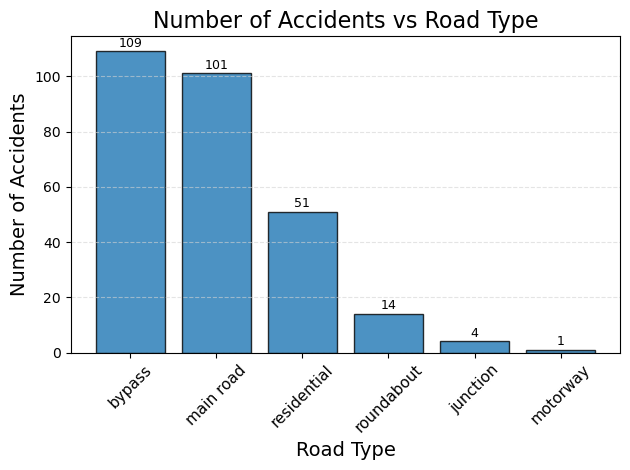

In [13]:
road_types_count = df['road_type'].value_counts()

labels = road_types_count.index
values = road_types_count.tolist()

bars = plt.bar(labels, values, edgecolor="black", alpha=0.8)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{int(height)}", ha="center", va="bottom", fontsize=9)

# Customize the chart
plt.title("Number of Accidents vs Road Type", fontsize=16)
plt.xticks(rotation=45, ha="center", fontsize=11)
plt.xlabel("Road Type", fontsize=14)
plt.ylabel("Number of Accidents", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6, color="#D3D3D3")
plt.tight_layout()
plt.show()

### Heatmap - Vehicle Count vs Severity

In [14]:
df['severity'].value_counts()

severity
high     140
High      69
fatal     24
med       24
Fatal     10
low        6
no         3
Low        3
High       1
Name: count, dtype: int64

In [15]:
df['vehicle_count'].value_counts()

vehicle_count
2.0    147
1.0    116
3.0     11
3.5      6
Name: count, dtype: int64

In [16]:
df['severity'] = df['severity'].apply(lambda x: x.lower().strip() if x != '' else 'unknown')

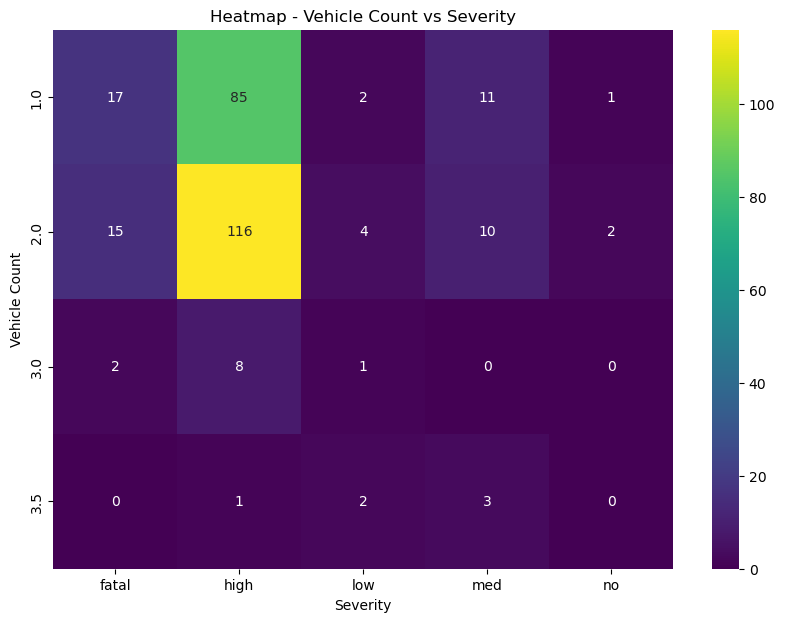

In [17]:
# Create contingency table
ct = pd.crosstab(df['vehicle_count'], df['severity'])

plt.figure(figsize=(10, 7))

# Draw heatmap
sns.heatmap(ct, annot=True, cmap="viridis", fmt='g')
plt.title('Heatmap - Vehicle Count vs Severity')
plt.ylabel('Vehicle Count')
plt.xlabel('Severity')
plt.show()